In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load th `seaice` dataset from the Seaborn library

In [2]:
seaice = sns.load_dataset("seaice")
seaice

,Date,Extent
0,1980-01-01,14.200
1,1980-01-03,14.302
2,1980-01-05,14.414
3,1980-01-07,14.518
4,1980-01-09,14.594
...,...,...
13170,2019-12-27,12.721
13171,2019-12-28,12.712
13172,2019-12-29,12.780
13173,2019-12-30,12.858


# Data preparation

- create *year* and *day-of-the-year* features from the seaice datetime feature.

In [3]:
seaice["year"] = seaice["Date"].dt.year
seaice["day"] = seaice["Date"].dt.dayofyear
seaice

,Date,Extent,year,day
0,1980-01-01,14.200,1980,1
1,1980-01-03,14.302,1980,3
2,1980-01-05,14.414,1980,5
3,1980-01-07,14.518,1980,7
4,1980-01-09,14.594,1980,9
...,...,...,...,...
13170,2019-12-27,12.721,2019,361
13171,2019-12-28,12.712,2019,362
13172,2019-12-29,12.780,2019,363
13173,2019-12-30,12.858,2019,364


# Matplotlib

**Note!** There are several years of measuring, so we can aggregate the dataset by the *day of year* (1st, 2nd...) feature

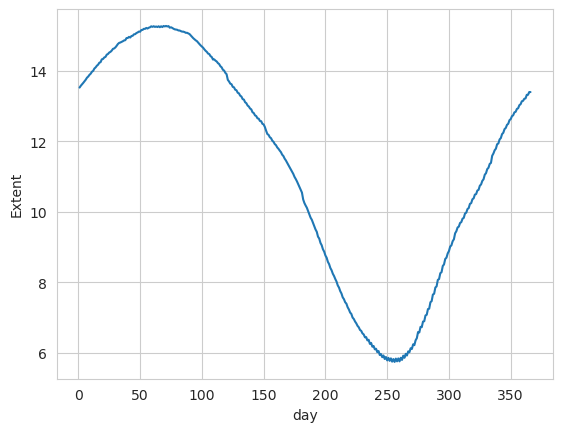

In [4]:
sns.set_style("whitegrid")
seaiceSimple = seaice.groupby(["day"])["Extent"].mean()
ax = seaiceSimple.plot(kind="line", x="day", y="Extent", label="mean")
plt.ylabel("Extent")
plt.show()

## Complex lineplot for every year

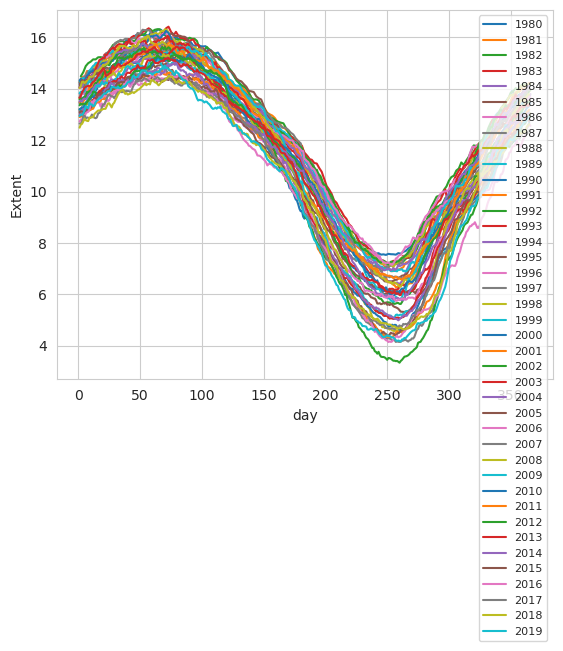

In [5]:
fig, ax = plt.subplots()
for year, seaiceDf in seaice.groupby("year"):
    seaiceDf.plot(kind="line", x="day", y="Extent", label=year, ax=ax)
plt.legend(fontsize=8)
plt.ylabel("Extent")
plt.show()

***

 - The line colours of the complex lineplot can be improved to indicate development over time.<br>
 We can create a colour palette.

In [6]:
colourPal = dict(zip(seaice["year"].unique(),sns.color_palette("light:b", n_colors=len(seaice["year"].unique()))))

**Code explanation**<br>
1. `seaice["year"].unique()`:
   - Gets all unique years from the *year* column in seaice.
   - Order is usually in the order they appear in the dataset.
2. `len(seaice["year"].unique())`
   - Counts how many unique years there are.
   - This will be used to know how many colors we need.
3. `sns.color_palette("light:b", n_colors=...)`
   - Generates a list of colors from Seaborn’s "light:b" palette (light blue shades in this case).
   - The number of colors equals the number of unique years, so each year gets its own color.
4. `zip(seaice["year"].unique(), [colors])`
   - Pairs each year with a unique color.
   - Example:
   ```
    (1979, color1), (1980, color2), ...
    
   ```
5. `dict(...)`
   - Turns those `(year, color)` pairs into a dictionary where:
     - Key = year (e.g., 1979)
     - Value = RGB tuple from the palette (e.g., (0.7, 0.85, 0.95))

    `



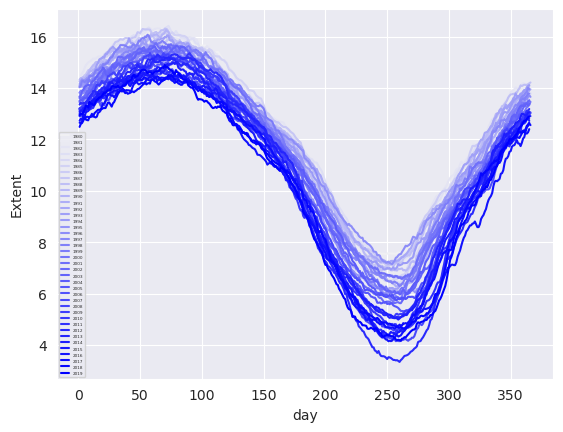

In [7]:
sns.set_style("darkgrid")
fig, ax = plt.subplots()
for year, seaiceDf in seaice.groupby("year"):
    seaiceDf.plot(kind="line", x="day", y="Extent", c=colourPal[year], label=year, ax=ax)
plt.legend(fontsize=3)
plt.ylabel("Extent")
plt.show()

## Complex lineplot for every decade

- Data handling

In [8]:
seaice["decade"] = seaice["year"]//10 * 10
seaice

,Date,Extent,year,day,decade
0,1980-01-01,14.200,1980,1,1980
1,1980-01-03,14.302,1980,3,1980
2,1980-01-05,14.414,1980,5,1980
3,1980-01-07,14.518,1980,7,1980
4,1980-01-09,14.594,1980,9,1980
...,...,...,...,...,...
13170,2019-12-27,12.721,2019,361,2010
13171,2019-12-28,12.712,2019,362,2010
13172,2019-12-29,12.780,2019,363,2010
13173,2019-12-30,12.858,2019,364,2010


In [9]:
seaiceAdv = seaice.groupby(["decade", "day"])["Extent"].describe()
seaiceAdv.reset_index(inplace=True, names=["decade", "day"])
seaiceAdv

,decade,day,count,mean,std,min,25%,50%,75%,max
0,1980,1,5.0,14.2012,0.095597,14.036,14.20000,14.2530,14.25600,14.261
1,1980,2,5.0,14.2490,0.175402,14.045,14.10300,14.3050,14.31300,14.479
2,1980,3,5.0,14.3516,0.073368,14.292,14.30200,14.3060,14.40200,14.456
3,1980,4,5.0,14.3906,0.166485,14.237,14.24000,14.4170,14.41700,14.642
4,1980,5,5.0,14.4426,0.048645,14.381,14.41400,14.4350,14.48900,14.494
...,...,...,...,...,...,...,...,...,...,...
1459,2010,362,10.0,12.6048,0.262353,12.235,12.35750,12.6905,12.82675,12.930
1460,2010,363,10.0,12.6993,0.267680,12.223,12.49375,12.7710,12.88125,13.097
1461,2010,364,10.0,12.7466,0.260744,12.273,12.56075,12.8020,12.90900,13.115
1462,2010,365,10.0,12.7912,0.230691,12.397,12.63325,12.7805,12.92050,13.180


- set up the colour palette

In [10]:
colourPal2 = dict(zip(seaiceAdv["decade"].unique(), sns.color_palette("Blues", n_colors=len(seaiceAdv["decade"].unique()))), as_cmap=True)

- create the plot

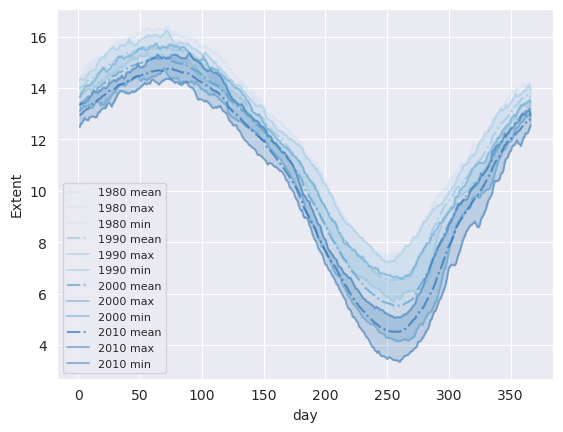

In [16]:
fig, ax = plt.subplots()
for decade, seaiceDf in seaiceAdv.groupby("decade"):
    mean = seaiceDf.plot(kind="line", x="day", y="mean", c=colourPal2[decade], label=f"{decade} mean", ax=ax, linestyle="-.", alpha=0.6)
    max = seaiceDf.plot(kind="line", x="day", y="max", c=colourPal2[decade], label=f"{decade} max", ax=ax, alpha=0.4)
    min = seaiceDf.plot(kind="line", x="day", y="min", c=colourPal2[decade], label=f"{decade} min", ax=ax, alpha=0.4)
    ax.fill_between(seaiceDf["day"], seaiceDf["min"], seaiceDf["max"], color=colourPal2[decade], alpha=0.2)
plt.legend(fontsize=8)
plt.ylabel("Extent")
plt.show()

### More general trend display

- Use the **1st and 3rd quartiles** to make the plot more visibly appealing and capture more of the general trend rather than extreme values

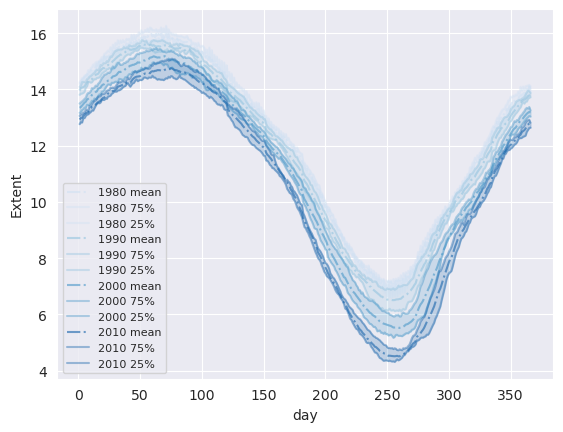

In [18]:
fig, ax = plt.subplots()
for decade, seaiceDf in seaiceAdv.groupby("decade"):
    mean = seaiceDf.plot(kind="line", x="day", y="mean", c=colourPal2[decade], label=f"{decade} mean", ax=ax, linestyle="-.", alpha=0.6)
    q75 = seaiceDf.plot(kind="line", x="day", y="75%", c=colourPal2[decade], label=f"{decade} 75%", ax=ax, alpha=0.4)
    q25 = seaiceDf.plot(kind="line", x="day", y="25%", c=colourPal2[decade], label=f"{decade} 25%", ax=ax, alpha=0.4)
    ax.fill_between(seaiceDf["day"], seaiceDf["25%"], seaiceDf["75%"], color=colourPal2[decade], alpha=0.2)
plt.legend(fontsize=8)
plt.ylabel("Extent")
plt.show()

***

- change the colour palette to be more informative

In [21]:
colourPal3 = dict(zip(seaiceAdv["decade"].unique(), sns.color_palette("bright", n_colors=len(seaiceAdv["decade"].unique()))), as_cmap=True)

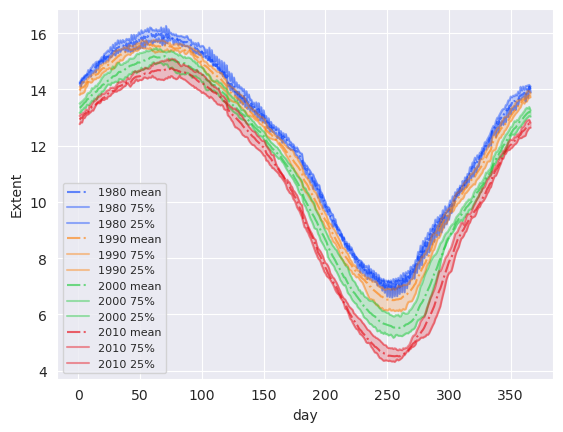

In [22]:
fig, ax = plt.subplots()
for decade, seaiceDf in seaiceAdv.groupby("decade"):
    mean = seaiceDf.plot(kind="line", x="day", y="mean", c=colourPal3[decade], label=f"{decade} mean", ax=ax, linestyle="-.", alpha=0.6)
    q75 = seaiceDf.plot(kind="line", x="day", y="75%", c=colourPal3[decade], label=f"{decade} 75%", ax=ax, alpha=0.4)
    q25 = seaiceDf.plot(kind="line", x="day", y="25%", c=colourPal3[decade], label=f"{decade} 25%", ax=ax, alpha=0.4)
    ax.fill_between(seaiceDf["day"], seaiceDf["25%"], seaiceDf["75%"], color=colourPal3[decade], alpha=0.2)
plt.legend(fontsize=8)
plt.ylabel("Extent")
plt.show()